In [2]:
import numpy as np
from scipy.linalg import expm, pinvh, LinAlgError
from scipy.special import comb
from scipy.integrate import *

import numba

import matplotlib.pyplot as plt


from electron_integrals import *
from CI_physicist import *

Define functions

In [19]:
# Function to get reduced density matrices

def get_RDMs(num_orbitals, num_electrons, C):
    slater_dets = CIHamiltonian.get_slater_dets(num_orbitals, num_electrons)
    C_conj = C.conj()

    D = np.zeros((num_orbitals,)*2 , dtype=np.cdouble)
    d = np.zeros((num_orbitals,)*4, dtype=np.cdouble)

    for n, det_n in enumerate(slater_dets):
        for m, det_m in enumerate(slater_dets):
            num_differences = np.sum(np.abs(det_n-det_m))
            match(num_differences):
                case 0:
                    for p, n_p in enumerate(det_n):
                        D[p,p] += n_p*C_conj[m]*C[n]
                        for r, n_r in enumerate(det_n):
                            d[p,r,p,r] += n_p*n_r*C_conj[m]*C[n]
                            d[p,r,r,p] -= n_p*n_r*C_conj[m]*C[n] # Note the sign                 
                case 2:
                    p = np.flatnonzero(np.asarray((det_m-det_n)==1))[0]
                    q = np.flatnonzero(np.asarray((det_n-det_m)==1))[0]
                    gamma = (-1)**(np.sum(det_n[:q])+np.sum(det_m[:p]))
                    D[p,q] += gamma*C_conj[m]*C[n]

                    for r, n_r in enumerate(det_n):
                        val = gamma*n_r*C_conj[m]*C[n]
                        d[p,r,q,r] += val
                        d[r,p,q,r] -= val # Note the sign
                        d[p,r,r,q] -= val # Note the sign
                        d[r,p,r,q] += val

                case 4:
                    p,q = np.flatnonzero(np.asarray((det_m-det_n)==1))
                    r,s = np.flatnonzero(np.asarray((det_n-det_m)==1))
                    
                    gamma = np.sum(det_n[:r])
                    gamma += np.sum(det_n[:s])-1 # -1 since r<s 
                    gamma += np.sum(det_n[:q])-int(s<q)-int(r<q)
                    gamma += np.sum(det_n[:p])-int(s<p)-int(r<p) # No additional term since p<q

                    val = C_conj[m]*C[n]*(-1)**gamma
                    d[p,q,r,s] += val
                    d[q,p,r,s] -= val # Note the sign
                    d[p,q,s,r] -= val # Note the sign
                    d[q,p,s,r] += val

    return D, d


# Helper functions to put the problem on a form handled by standard SciPy ODE solvers 
#@numba.njit
def Cb_to_y(C, b):
    return np.concatenate([C.flatten(), b.flatten()])

#@numba.njit
def y_to_Cb(y, num_mctdhf_orbitals, num_spin_orbitals, num_slater_dets):

    C, b = np.split(y, [num_slater_dets])
    b = b.reshape((num_spin_orbitals, num_mctdhf_orbitals))

    return C, b

Define number of electrons and orbitals

In [4]:
# Number of orbitals (without spin)
num_orbitals = 6
# Number of electrons
num_electrons = 1
#Include spin?
include_spin = False
spin_factor = 1+int(include_spin)

num_spin_orbitals = spin_factor*num_orbitals

Calculate electron integrals

In [5]:
x_max = 10
num_points = 1000

x = np.linspace(-x_max,x_max,num_points)

#pot = GaussianWell(w=100, a=1, center=0)
pot = HOPotential()

spf, h = get_spf_and_diag_h(num_orbitals, x, pot)

if include_spin:
    #Add spin
    h = np.kron(h, np.eye(2,2))

g = coulomb_interaction_matrix_elements(spf, spf, x, x, kappa = 1, a = 0.01)

if include_spin:
    #Add spin
    g = np.kron(g, np.einsum("pr,qs->pqrs",np.eye(2,2), np.eye(2,2)))

print('Sanity test, due to symmetry in g this should be zero:')
print(-g[2,1,1,0]+g[2,0,1,1]+g[1,1,2,0]-g[1,0,2,1])

Sanity test, due to symmetry in g this should be zero:
0.0


# Only using single particle operators

Solve using Slater-Condon 

In [6]:
zeros = np.zeros_like(g)

H = SlaterCondonHamiltonian(num_spin_orbitals, num_electrons, h, zeros).get_hamiltonian()
E_CI, C_CI = np.linalg.eigh(H)
print(E_CI)
#print(C_CI[:,0].T@H@C_CI[:,0])

#print(C_CI.conj().T@C_CI)

D, d = get_RDMs(num_spin_orbitals, num_electrons, C_CI[:,0])
E_rdm = np.einsum('pq, pq', D, h) + 0.5 * np.einsum('pqrs, pqrs', zeros, d)
print(E_rdm)

np.testing.assert_almost_equal(E_CI[0], E_rdm)


[0.49998747 1.49993737 2.49983716 3.49968685 4.49948641 5.49923587]
(0.49998747464902416+0j)


# Orbital equations

Define number of MCTDHF orbitals $(\{\ket{\phi_n(t)}\})$, initial b's (basis reduction coefficients),

$\ket{\phi_n(t)} = \sum_{k=1}^{N_b}b_{kn}(t)\ket{\psi_k}$,

and initial C's.


In [7]:
num_mctdhf_orbitals = 5
num_mctdhf_slater_dets = int(comb(num_mctdhf_orbitals, num_electrons))

# Distributed vales
#b_init = np.zeros((num_spin_orbitals, num_mctdhf_orbitals))
#a = int(num_spin_orbitals/num_mctdhf_orbitals)
#for i in range(num_mctdhf_orbitals):
#    b_init[a*i:a*(i+1), i] = np.ones(a)

# Identity
#b_init=np.eye(num_spin_orbitals, num_mctdhf_orbitals)

# Generate random orthonormal vectors
rng = np.random.default_rng()
r = rng.random((num_spin_orbitals, num_mctdhf_orbitals))
u, _, vh = np.linalg.svd(r, full_matrices=False)
b_init = (u@vh).astype(np.cdouble)

print(b_init)

# Ones as initial C
#C_init = np.ones((num_mctdhf_slater_dets), dtype=np.cdouble)

# Random initial C
C_init = rng.random(num_mctdhf_slater_dets).astype(np.cdouble)

#Normalize
C_init = np.divide(C_init, np.sqrt(C_init.T.conj()@C_init))

#C_init = np.zeros(num_mctdhf_slater_dets).astype(np.cdouble)
#C_init[0] = 1

print(C_init)

[[ 0.21099503+0.j -0.33841857+0.j -0.20963564+0.j  0.48496953+0.j
   0.65839162+0.j]
 [-0.15514916+0.j  0.71756989+0.j  0.15874707+0.j  0.37757367+0.j
  -0.09872996+0.j]
 [ 0.54994158+0.j  0.22275258+0.j  0.404839  +0.j -0.55574098+0.j
   0.36689813+0.j]
 [-0.36785285+0.j  0.11610167+0.j  0.57020837+0.j  0.22426192+0.j
   0.46908456+0.j]
 [ 0.44919468+0.j  0.50489107+0.j -0.45648962+0.j  0.19708035+0.j
   0.1144874 +0.j]
 [ 0.54026152+0.j -0.22924445+0.j  0.48315348+0.j  0.47356157+0.j
  -0.4347539 +0.j]]
[0.20433204+0.j 0.2436487 +0.j 0.48114565+0.j 0.46810634+0.j
 0.66952151+0.j]


Define callable class for the differential equations

In [34]:
class MCDTHF_imaginary_time:
    def __init__(self, h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons):
        self.h = h
        self.g = g
        self.num_mctdhf_orbitals = num_mctdhf_orbitals
        self.num_spin_orbitals = num_spin_orbitals
        self.num_electrons = num_electrons
        self.num_slater_dets = int(comb(num_mctdhf_orbitals, num_electrons))
        self.I = np.eye(self.num_slater_dets)

    #@numba.jit
    # def get_hs(self, b, h):
    #     h_1 = np.einsum('jm, ij -> im', b, h)
    #     h_2 = np.einsum('in, im -> nm', b.conj(), h_1)
    #     h_3 = np.einsum('in, nm -> im', b, h_2)
    #     return h_1, h_2, h_3
        
    
    def __call__(self, t, y):
        
        C, b = y_to_Cb(y, self.num_mctdhf_orbitals, self.num_spin_orbitals, self.num_slater_dets)
        bc = b.conj()

        #h_1, h_2, h_3 = self.get_hs(b, h)

        h_1 = np.einsum('jm, ij -> im', b, self.h)
        h_2 = np.einsum('in, im -> nm', bc, h_1)
        h_3 = np.einsum('in, nm -> im', b, h_2)

        # h_1 = self.h@b
        # h_2 = bc.T@h_1
        # h_3 = b@h_2

        b_dot = -(h_1-h_3)


        H = SlaterCondonHamiltonian(self.num_mctdhf_orbitals, self.num_electrons, h_2, np.zeros((self.num_mctdhf_orbitals, )*4)).get_hamiltonian()

        ## From Beck paper, replacing HC with (H-IE)C should keep the wave function normalized (should be able to remove renormalization further down)
        E = C.conj().T@H@C/(C.conj().T@C)
        C_dot = - (H-self.I*E)@C 
    
        ## Regular way
        #C_dot = -H@C


        return Cb_to_y(C_dot, b_dot)

Solve using ODE solver

In [35]:
#mctdhf_fun = MCDTHF(h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)
mctdhf_fun = MCDTHF_imaginary_time(h, zeros, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)

y_init = Cb_to_y(C_init, b_init)

Cs = np.copy(C_init).reshape(1,-1)
bs = [np.copy(b_init)]
bs.append(b_init)

#H = SlaterCondonHamiltonian(num_mctdhf_orbitals, num_electrons, h_2, np.zeros((num_mctdhf_orbitals, )*4)).get_hamiltonian()
Es = np.array([])

t_init = 0
t_final = 3.0
#solver = DOP853(mctdhf_fun, t_init, y_init, t_final, max_step = 0.001)
solver = RK45(mctdhf_fun, t_init, y_init, t_final, max_step = 0.001)
#solver = RK23(mctdhf_fun, t_init, y_init, t_final, max_step = 0.001)

while solver.status == 'running':
    msg = solver.step()

    C, b = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spin_orbitals, num_mctdhf_slater_dets)
    # Normalize every step during imaginary time prop
    C = np.divide(C, np.sqrt(C.T.conj()@C))
    b = np.divide(b, np.sqrt(np.einsum('ij, ij -> j', b.conj(), b)))

    ## Test to make sure b_dot is orthogonal to b (otherwise orthonormality will be lost.)  
    h_1 = np.einsum('jm, ij -> im', b, h)
    h_2 = np.einsum('in, im -> nm', b.conj(), h_1)
    # h_3 = np.einsum('in, nm -> im', b, h_2)
    # b_dot = -(h_1-h_3)
    # print(f'b@b_dot = \n{b.T.conj()@b_dot}')

    H = SlaterCondonHamiltonian(num_mctdhf_orbitals, num_electrons, h_2, np.zeros((num_mctdhf_orbitals, )*4)).get_hamiltonian()

    #D, d = get_RDMs(num_mctdhf_orbitals, num_electrons, C)

    #Es = np.append(Es, np.real(np.einsum('pq, pq', D, h_2)))
    Es = np.append(Es, np.real(C.conj().T@H@C))
    Cs = np.append(Cs, C.reshape(1,-1), axis=0)
    bs.append(b)

    solver.y = Cb_to_y(C, b)
else:
    if solver.status != 'finished':
        raise(RuntimeError(msg))

Final b =
[[ 0.27450808+0.j -0.27408115+0.j -0.22027057+0.j  0.56676217+0.j
   0.69273284+0.j]
 [-0.02772368+0.j  0.83530458+0.j  0.14099909+0.j  0.5287678 +0.j
  -0.04629728+0.j]
 [ 0.62110739+0.j  0.27852327+0.j  0.39877395+0.j -0.48017069+0.j
   0.38371107+0.j]
 [-0.67429144+0.j -0.05362031+0.j  0.56172204+0.j -0.05903016+0.j
   0.4729178 +0.j]
 [-0.27551199+0.j  0.36887759+0.j -0.65262583+0.j -0.3909742 +0.j
   0.36749882+0.j]
 [ 0.08675552+0.j -0.10307646+0.j  0.17642943+0.j  0.11079702+0.j
  -0.10971305+0.j]]
Final C =
[ 0.27442489+0.j -0.24747923+0.j -0.21502739+0.j  0.58213398+0.j
  0.6916128 +0.j]
Final E =
0.5010092571460856
Overlap matrix for final b:
[[ 1.00000000e+00+0.j  1.80718214e-04+0.j -3.45516284e-04+0.j
  -1.82290492e-04+0.j  1.17109306e-04+0.j]
 [ 1.80718214e-04+0.j  1.00000000e+00+0.j  1.72547769e-04+0.j
   1.27663939e-04+0.j -1.51967162e-04+0.j]
 [-3.45516284e-04+0.j  1.72547769e-04+0.j  1.00000000e+00+0.j
  -2.15633854e-04+0.j  3.49961956e-04+0.j]
 [-1.82290492e

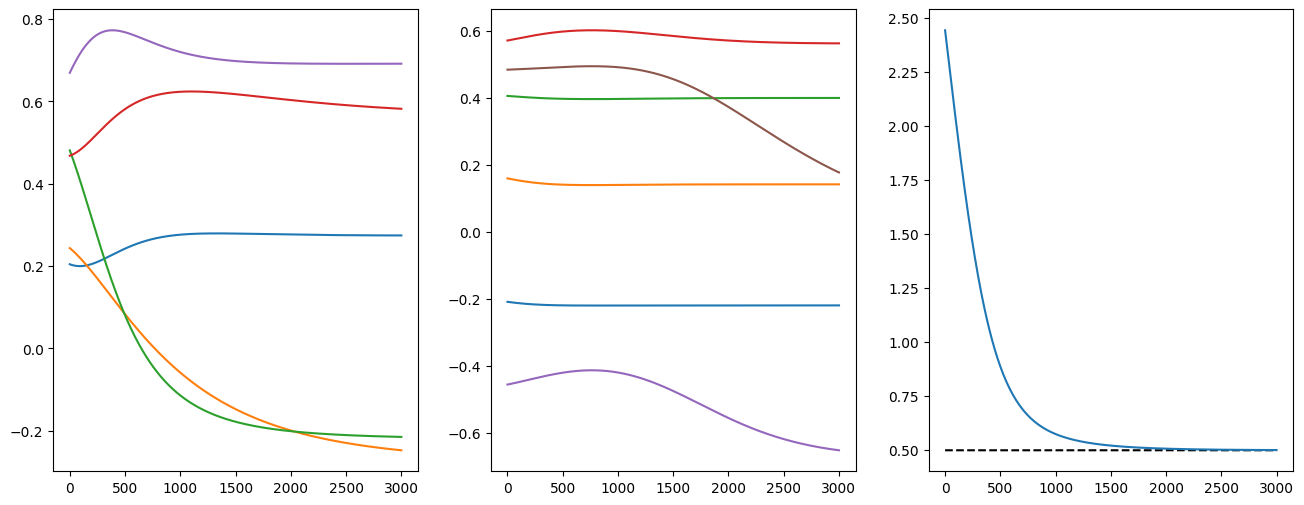

In [36]:
C_f, b_f = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spin_orbitals, num_mctdhf_slater_dets)
print(f"Final b =\n{b_f}")
print(f"Final C =\n{C_f}")
print(f"Final E =\n{Es[-1]}")

print(f"Overlap matrix for final b:\n{b_f.T@b_f}")

b_arr = np.array(bs)

fig, ax = plt.subplots(1, 3, figsize=(16,6))
ax[0].plot(np.real(Cs))
ax[1].plot(np.real(b_arr.reshape(b_arr.shape[0],*b_init.shape)[:,:,2]))
ax[2].plot(np.arange(Cs.shape[0]), 0.5*np.ones(Cs.shape[0]), 'k--')
ax[2].plot(Es)
plt.show()

In [11]:
print(solver.step_size)

2.1938006966593093e-13
